In [40]:
# ============ #
# 1. LIBRERÍAS #
# ============ #

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import mean_absolute_percentage_error

In [41]:
# =================== #
# 2. LECTURA DE RUTAS #
# =================== #

mainpath = os.path.join(os.getcwd(), "..", "..", "data", "raw")
filename = "job_salary_prediction_dataset.csv"
fullpath = os.path.join(mainpath, filename)

In [42]:
# ================= #
# 3. CARGA DE DATOS #
# ================= #

df = pd.read_csv(fullpath, sep=",") # El separador es "," porque en el archivo .csv los valores están separados por coma
pd.set_option('display.max_columns', None) # Para mostrar todas las columnas del DataFrame sin truncar

In [43]:
# ============================== #
# 4. IDENTIFICACIÓN DE VARIABLES #
# ============================== #

def variables(df = df):
    float_cols = df.select_dtypes(include='float64').columns.tolist()
    int_cols = df.select_dtypes(include='int64').columns.tolist()
    cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
    target = 'salary'
    features = [col for col in float_cols + int_cols if col != target]
    return features, target, cat_cols

features, target, cat_cols = variables()


C:\Users\saria\AppData\Local\Temp\ipykernel_1284\2578039198.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()


In [44]:
# ================================================================================================================== #
# 4. ONE-HOT ENCODING (A las variables categóricas aplícales One-Hot Encoding, 
# y a las numéricas déjalas como están) #
# ================================================================================================================== #
 
preprocessor = ColumnTransformer([
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_cols),
    ('num', StandardScaler(), features)
])

In [45]:
# =============================== #
# VISUALIZAR EL PRE-PROCESAMIENTO #
# =============================== #

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e.g. `

In [46]:
# ============================= #
# 5. MOSTRAR LA BASE CODIFICADA #
# ============================= #
 
X = df[cat_cols + features]
X_encoded = preprocessor.fit_transform(X)
feature_names = preprocessor.get_feature_names_out()
X_encoded_df = pd.DataFrame.sparse.from_spmatrix(X_encoded, columns=feature_names)
X_encoded_df.sample(20)

,cat__job_title_Backend Developer,cat__job_title_Business Analyst,cat__job_title_Cloud Engineer,cat__job_title_Cybersecurity Analyst,cat__job_title_Data Analyst,cat__job_title_Data Scientist,cat__job_title_DevOps Engineer,cat__job_title_Frontend Developer,cat__job_title_Machine Learning Engineer,cat__job_title_Product Manager,cat__job_title_Software Engineer,cat__education_level_Diploma,cat__education_level_High School,cat__education_level_Master,cat__education_level_PhD,cat__industry_Education,cat__industry_Finance,cat__industry_Government,cat__industry_Healthcare,cat__industry_Manufacturing,cat__industry_Media,cat__industry_Retail,cat__industry_Technology,cat__industry_Telecom,cat__company_size_Large,cat__company_size_Medium,cat__company_size_Small,cat__company_size_Startup,cat__location_Canada,cat__location_Germany,cat__location_India,cat__location_Netherlands,cat__location_Remote,cat__location_Singapore,cat__location_Sweden,cat__location_UK,cat__location_USA,cat__remote_work_No,cat__remote_work_Yes,num__experience_years,num__skills_count,num__certifications
7881,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,-1.155895,0.365411,-0.874276
187701,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-1.650897,-0.91213,-0.288272
8029,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,-0.330893,1.642952,-0.874276
137041,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,-1.320896,-1.094636,0.297732
139195,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,-0.825894,1.095434,-0.288272
61311,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,0.659109,-0.91213,0.883737
248469,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.330893,0.912928,-0.288272
67989,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,0.659109,-0.547118,-1.460281
34433,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.494109,-0.729624,-0.874276
85152,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN,1.0,NaN,1.484112,0.912928,0.297732


In [47]:
# ============================================= #
# 6. MOSTRAR LAS COLUMNAS DE LA BASE CODIFICADA #
# ============================================= #
X_encoded_df.columns.tolist()

['cat__job_title_Backend Developer',
 'cat__job_title_Business Analyst',
 'cat__job_title_Cloud Engineer',
 'cat__job_title_Cybersecurity Analyst',
 'cat__job_title_Data Analyst',
 'cat__job_title_Data Scientist',
 'cat__job_title_DevOps Engineer',
 'cat__job_title_Frontend Developer',
 'cat__job_title_Machine Learning Engineer',
 'cat__job_title_Product Manager',
 'cat__job_title_Software Engineer',
 'cat__education_level_Diploma',
 'cat__education_level_High School',
 'cat__education_level_Master',
 'cat__education_level_PhD',
 'cat__industry_Education',
 'cat__industry_Finance',
 'cat__industry_Government',
 'cat__industry_Healthcare',
 'cat__industry_Manufacturing',
 'cat__industry_Media',
 'cat__industry_Retail',
 'cat__industry_Technology',
 'cat__industry_Telecom',
 'cat__company_size_Large',
 'cat__company_size_Medium',
 'cat__company_size_Small',
 'cat__company_size_Startup',
 'cat__location_Canada',
 'cat__location_Germany',
 'cat__location_India',
 'cat__location_Netherlands

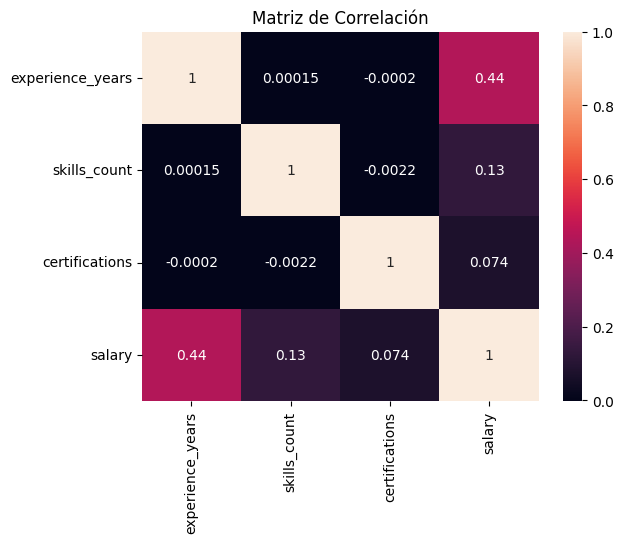

In [48]:
# ===================================================== #
# 7. ANÁLISIS DE CORRELACIÓN (Solo variables numéricas) #
# ===================================================== #

corr = df[features + [target]].corr()

plt.figure()
sns.heatmap(corr, annot=True)
plt.title("Matriz de Correlación")
plt.show()

In [49]:
# ========================= #
# 8. PARTICIÓN TRAIN / TEST #
# ========================= #

X = df[features + cat_cols] 
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [50]:
# ====================== #
# 9. MODELO DE REGRESIÓN #
# ====================== #

model = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transforme

In [51]:
# ============== #
# 10. EVALUACIÓN #
# ============== #

y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = mean_absolute_percentage_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("RMSE:", rmse)
print("MAPE:", mape)
print("MAPE(%):", mape * 100)
print("R2:", r2)

MAE: 5469.155709358589
RMSE: 7170.5284274196265
MAPE: 0.04161551719641044
MAPE(%): 4.161551719641044
R2: 0.9631042999144008


In [52]:
# ======================================== #
# 10.1. DATAFRAME CON RESULTADOS Y ERRORES # 
# ======================================== #

# Asegurar formatos
X_test_df = pd.DataFrame(X_test).reset_index(drop=True)
y_test_df = pd.Series(y_test).reset_index(drop=True)
y_pred_df = pd.Series(y_pred)

# Construir DataFrame final
df_resultados = X_test_df.copy()
df_resultados["y_real"] = y_test_df
df_resultados["y_pred"] = y_pred_df

df_resultados["error"] = df_resultados["y_real"] - df_resultados["y_pred"]
df_resultados["abs_error"] = df_resultados["error"].abs()

df_resultados.sample(20)

,experience_years,skills_count,certifications,job_title,education_level,industry,company_size,location,remote_work,y_real,y_pred,error,abs_error
68969,18,14,2,Software Engineer,Bachelor,Finance,Medium,India,No,88726,108246.139590,-19520.139590,19520.139590
30012,12,11,2,Backend Developer,High School,Technology,Startup,Sweden,Yes,110712,109692.492028,1019.507972,1019.507972
12821,14,1,3,AI Engineer,High School,Education,Small,Sweden,Hybrid,146629,144111.825236,2517.174764,2517.174764
58575,1,1,0,Business Analyst,PhD,Healthcare,Small,India,Yes,63051,48441.625022,14609.374978,14609.374978
59296,19,7,2,Cloud Engineer,Bachelor,Media,Enterprise,Singapore,Yes,198631,191203.450888,7427.549112,7427.549112
33193,13,9,1,Data Scientist,Bachelor,Telecom,Enterprise,Singapore,Yes,165539,169616.459124,-4077.459124,4077.459124
53457,10,13,2,Business Analyst,Master,Education,Large,Australia,No,134277,133328.021616,948.978384,948.978384
13281,20,9,0,Software Engineer,Diploma,Healthcare,Medium,Remote,No,137361,142632.887603,-5271.887603,5271.887603
73351,7,7,5,Data Analyst,PhD,Technology,Medium,UK,Hybrid,130867,140294.715805,-9427.715805,9427.715805
23902,11,2,5,Backend Developer,Diploma,Telecom,Startup,Australia,Yes,109294,109508.237425,-214.237425,214.237425


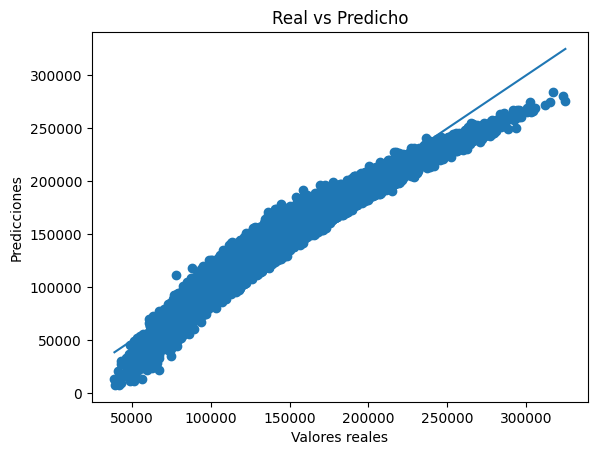

In [53]:
# ====================== #
# 10.2. REAL VS PREDICHO #
# ====================== #

plt.scatter(df_resultados["y_real"], df_resultados["y_pred"])
plt.xlabel("Valores reales")
plt.ylabel("Predicciones")
plt.title("Real vs Predicho")

# Línea ideal
plt.plot(
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()],
    [df_resultados["y_real"].min(), df_resultados["y_real"].max()]
)

plt.show()

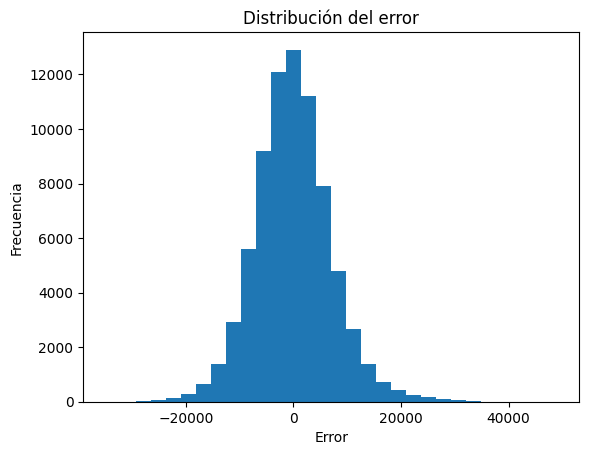

In [54]:
# ============================= #
# 10.3. DISTRIBUCIÓN DE ERRORES #
# ============================= #

plt.hist(df_resultados["error"], bins=30)
plt.title("Distribución del error")
plt.xlabel("Error")
plt.ylabel("Frecuencia")
plt.show()

#========================#
#===VALIDACIÓN CRUZADA===#

In [57]:
from sklearn.model_selection import cross_validate
from sklearn.linear_model import LinearRegression # O el modelo que estés usando
import numpy as np
import pandas as pd

# 1. Instanciamos el modelo (Asegúrate de que 'modelo' sea el que quieres evaluar)
modelo_lr = LinearRegression()

# 2. Definimos las métricas solicitadas
scoring = {
    'mae': 'neg_mean_absolute_error',
    'rmse': 'neg_root_mean_squared_error',
    'r2': 'r2'
}

# 3. Ejecutamos la Validación Cruzada con 10 Folds
# Ajusta 'X_train' y 'y_train' a los nombres de tus variables
cv_results = cross_validate(model, X_train, y_train, cv=10, scoring=scoring, return_train_score=False)

# 4. Procesamos los resultados para que sean legibles (Punto b de tu tarea)
mae_scores = -cv_results['test_mae']
rmse_scores = -cv_results['test_rmse']
r2_scores = cv_results['test_r2']

print("--- RESULTADOS VALIDACIÓN CRUZADA (10-FOLD) ---")
print(f"MAE  Promedio: {mae_scores.mean():.4f} (Std: {mae_scores.std():.4f})")
print(f"RMSE Promedio: {rmse_scores.mean():.4f} (Std: {rmse_scores.std():.4f})")
print(f"R²   Promedio: {r2_scores.mean():.4f}")

--- RESULTADOS VALIDACIÓN CRUZADA (10-FOLD) ---
MAE  Promedio: 5463.4061 (Std: 21.1331)
RMSE Promedio: 7155.3647 (Std: 36.0055)
R²   Promedio: 0.9635
